In [ ]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openquake.commonlib.datastore import read
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'openquake'

In [2]:
!oq engine --lrc

job_id |     status |          start_time |         description
     1 |   complete | 2024-11-03 12:06:15.308445 | Scenario Risk Demo (Catania Tsunami) using hysea simulation no aggregation
     2 |   complete | 2024-11-03 12:06:35.087976 | Scenario Risk Demo (Catania Tsunami) using emulation results with training size 892 no aggregation
     3 |   complete | 2024-11-03 12:06:54.806854 | Scenario Risk Demo (Catania Tsunami) using emulation results with training size 1658 no aggregation
     4 |   complete | 2024-11-03 12:07:16.469549 | Scenario Risk Demo (Catania Tsunami) using emulation results with training size 3454 no aggregation
     5 |   complete | 2024-11-03 12:12:18.075475 | Scenario Risk Demo (Catania Tsunami) using emulation results with training size 7071 no aggregation
     6 |   complete | 2024-11-03 13:17:53.362380 | Scenario Risk Demo (Catania Tsunami) using hysea simulation with foglio aggregation
     7 |   complete | 2024-11-03 13:19:15.386250 | Scenario Risk Demo (C

In [3]:
dstore = read(66)
list(dstore)

['agg_keys',
 'agg_values',
 'assetcol',
 'avg_losses-rlzs',
 'crm',
 'discarded',
 'events',
 'exposure',
 'full_lt',
 'gmf_data',
 'oqparam',
 'performance_data',
 'risk_by_event',
 'rupgeoms',
 'ruptures',
 'sitecol',
 'task_info',
 'task_sent',
 'taxmap',
 'weights']

In [4]:
dstore.read_df('risk_by_event').head()
# dstore.close()

,event_id,agg_id,loss_id,variance,loss
0,2735,140,3,0.0,1.086422e+06
1,2738,140,3,0.0,1.340020e+06
2,2739,140,3,0.0,6.341632e+05
3,2740,140,3,0.0,1.478937e+06
4,2741,140,3,0.0,2.752597e+05


In [5]:
event_info = pd.read_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/info/sampling_input_CT_38.csv',header=0)
event_info['event_id']= event_info.index

run_name = ['true','mean','sigmaminus','sigmaplus']

for i,job_id in enumerate([66,67,68,69]):
    print(f'Job {job_id} for {run_name[i]}')
    # Load the results
    dstore = read(job_id)

    # Extract the data
    data_event = dstore.read_df('risk_by_event')
    #aggregate the data based on event_id
    event_loss = data_event.groupby('event_id')['loss'].sum()

    #number of events
    print('Number of events:', len(event_loss))

    #save the data to a csv file
    event_loss.to_csv(f'1_event_only_loss_{run_name[i]}.csv', index=True)

    #append event_loss to event_info
    event_info = event_info.join(event_loss, on='event_id', rsuffix=f'_{run_name[i]}')

#rename column loss to loss_true
event_info.rename(columns={'loss':'loss_true'}, inplace=True)

#set missing values to 0
event_info[f'loss_true'] = event_info[f'loss_true'].fillna(0)
event_info[f'loss_mean'] = event_info[f'loss_mean'].fillna(0)
event_info[f'loss_sigmaminus'] = event_info[f'loss_sigmaminus'].fillna(0)
event_info[f'loss_sigmaplus'] = event_info[f'loss_sigmaplus'].fillna(0)

#save the data to a csv file
# event_info.to_csv('3_event_info_loss_uncertainty.csv', index=False)


Job 66 for true
Number of events: 43895
Job 67 for mean
Number of events: 53544
Job 68 for sigmaminus
Number of events: 39141
Job 69 for sigmaplus
Number of events: 53550


In [11]:
def get_loss_pml(loss,rate,threshold,PoE):

    total_value = 28491684200

    #filter events based on threshold of 500
    print('Number of events before filtering:', len(loss))
    rate = rate[loss>threshold]
    loss = loss[loss>threshold]
    print('Number of events after filtering:', len(loss))

    #reset index
    rate = rate.reset_index(drop=True)
    loss = loss.reset_index(drop=True)

    #sort descending
    idx = np.argsort(loss)[::-1]
    sorted_loss = loss[idx]
    sorted_rate = rate[idx]  
    

    #Event loss table
    ELT = pd.DataFrame({'loss':sorted_loss,'rate':sorted_rate})
    ELT['weighted_loss'] = sorted_loss*sorted_rate
    ELT['cumulative_probability'] = ELT['rate'].cumsum()

    AAL = np.sum(ELT['weighted_loss'])
    print('AAL:',AAL,'\n')

    PML = np.zeros(len(PoE))
    PML_ratio = np.zeros(len(PoE))
    #find the event loss for each RP
    for i,probability_level in enumerate(PoE):
        PML[i] = ELT['loss'][ELT['cumulative_probability']>probability_level].max()
        if PML[i] == np.nan:
            PML_ratio[i] = 0
        else:
            PML_ratio[i] = PML[i]/total_value

    return PML,PML_ratio,ELT

Number of events before filtering: 53550
Number of events after filtering: 30669
AAL: 37930.58124196895 

Number of events before filtering: 53550
Number of events after filtering: 29904
AAL: 43517.963976663974 

Number of events before filtering: 53550
Number of events after filtering: 23329
AAL: 23048.307090488226 

Number of events before filtering: 53550
Number of events after filtering: 42191
AAL: 76979.52778683775 



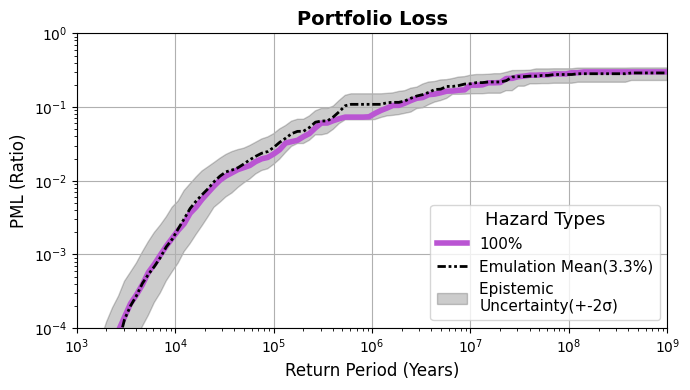

In [7]:
#get probability of exceedance thresholds using RPs from 1 in 10 to 1 in 10e8
RP = [10, 20, 50,
      100, 200, 500, 
      1000, 2000, 5000,
      10000, 20000, 50000, 100000, 200000, 
      2000000, 5000000, 10000000, 20000000, 50000000, 
      100000000, 200000000, 500000000, 1000000000]

RP = np.logspace(3, 9, num=100, base=10).astype(int)  # 10^3 to 10^9

PoE = [1/rp for rp in RP]

min_loss = 500

PML_true = get_loss_pml(event_info['loss_true'],event_info['mean_prob'],min_loss,PoE)[1]
PML_mean = get_loss_pml(event_info['loss_mean'],event_info['mean_prob'],min_loss,PoE)[1]
PML_sigmaminus = get_loss_pml(event_info['loss_sigmaminus'],event_info['mean_prob'],min_loss,PoE)[1]
PML_sigmaplus = get_loss_pml(event_info['loss_sigmaplus'],event_info['mean_prob'],min_loss,PoE)[1]

# plot
fig, ax = plt.subplots(figsize=(7, 4))

# Plot the true simulation
ax.plot(RP, PML_true, label='100%', color='mediumorchid',linewidth=4, alpha=1)

# Plot the mean emulation as solid line
ax.plot(RP, PML_mean, label='Emulation Mean(3.3%)', color='#000000', linestyle=(0, (3, 1, 1, 1, 1, 1)),linewidth=2)

# Fill between sigma minus and sigma plus
ax.fill_between(RP, PML_sigmaminus, PML_sigmaplus, color='#000000', alpha=0.2,label= f'Epistemic \nUncertainty(+-2σ)')

# Log scales
ax.set_xscale('log')
ax.set_yscale('log')

# Labels and title
ax.set_xlabel('Return Period (Years)', fontsize=12)
ax.set_ylabel('PML (Ratio)', fontsize=12)
ax.set_title('Portfolio Loss', fontsize=14, fontweight='bold')

# Limits
ax.set_ylim(1e-4, 1e0)
ax.set_xlim(1e3, 1e9)
ax.grid()

# Grid
# ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Legend
ax.legend(title='Hazard Types', title_fontsize=13, fontsize=11)

# Ticks
ax.tick_params(axis='both', which='major', labelsize=10)

# Layout and show
plt.tight_layout()
plt.savefig('portfolio_loss_stochasticemulation.png', dpi=300, bbox_inches='tight',transparent=False)
plt.show()

Number of events before filtering: 53550
Number of events after filtering: 30669
AAL: 37930.58124196895 

Number of events before filtering: 53550
Number of events after filtering: 31045
AAL: 20169.989239660295 



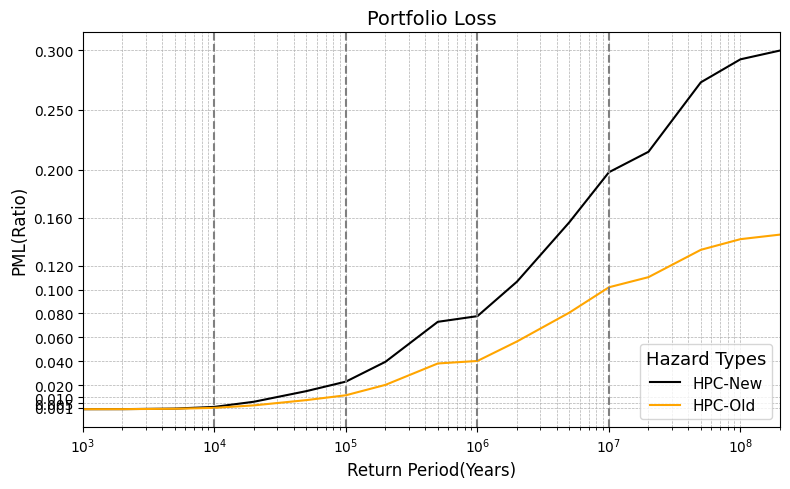

In [8]:
#read event_info
# event_info = pd.read_csv('3_event_info_loss_uncertainty.csv')
event_info_old = pd.read_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/results/3_event_info_agg_loss.csv')

# get probability of exceedance thresholds using RPs from 1 in 10 to 1 in 10e8
RP = [10, 20, 50,
      100, 200, 500, 
      1000, 2000, 5000,
      10000, 20000, 50000, 
      100000, 200000, 500000, 
      1000000, 2000000, 5000000, 
      10000000, 20000000, 50000000, 
      100000000, 200000000, 500000000, 1000000000]

PoE = [1/rp for rp in RP]

# Set minimum loss threshold
min_loss = 500

# Compute PML values
PML_true = get_loss_pml(event_info['loss_true'], event_info['mean_prob'], min_loss, PoE)[1]
PML_old = get_loss_pml(event_info_old['loss_true'],event_info_old['mean_prob'],min_loss,PoE)[1]
# PML_mean = get_loss_pml(event_info['loss_mean'], event_info['mean_prob'], min_loss, PoE)[1]

#plot
fig, ax = plt.subplots(figsize=(8, 5))
# Plot true PML
#remove some repetitive rows from RP and PML_true based on unique values in PML_true
ax.plot(RP, PML_true, label='HPC-New', color='k', linewidth=1.5)
ax.plot(RP, PML_old, label='HPC-Old', color='orange', linewidth=1.5)

# Total value (for event count annotations)
total_value = 28491684200
thresholds = [1e-4, 1e-5, 1e-6, 1e-7, 1e-8]

#draw vertical line exceed threshold probability of 1e4, 1e6, 1e8
ax.axvline(x=1e4, color='grey', linestyle='--')
ax.axvline(x=1e5, color='grey', linestyle='--')
ax.axvline(x=1e6, color='grey', linestyle='--')
ax.axvline(x=1e7, color='grey', linestyle='--')


ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Return Period(Years)', fontsize=12)
ax.set_ylabel('PML(Ratio)', fontsize=12)
ax.set_title('Portfolio Loss', fontsize=14)
ax.set_xlim(1e3, 2e8)
# ax.set_ylim(1e-5, 2e-1)
ax.set_yticks([0.001, 0.005, 0.01, 0.02, 0.04,.06,.08,.1,.12,.16,.20,.25,.3]) 
# Add grid lines
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Customize legend
ax.legend(title='Hazard Types', title_fontsize='13', fontsize='11')

# Customize ticks
ax.tick_params(axis='both', which='major', labelsize=10)

# Show plot
plt.tight_layout()
plt.show()


In [9]:
file = '/home/naveen.raguramalinga/oqdata/calc_66.hdf5'

with h5py.File(file, 'r') as f:
    agg_keys = f['agg_keys'][:]
    f.close()

# remove b in string values in the np array agg_keys,ex b'19089001000000292200' to 19089001000000292200
agg_keys = np.array([x.decode('utf-8') for x in agg_keys])

# convert the np array to a pandas dataframe
agg_keys = pd.DataFrame(agg_keys, columns=['foglio_id'])
agg_keys['agg_id'] = agg_keys.index 
num_keys = len(agg_keys)
#last key is the aggregated sum for the whole event

#save IDAG and agg_id key to a csv file
agg_keys.to_csv('0_foglio_keys.csv', index=False)

In [ ]:
event_info = pd.read_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/info/sampling_input_CT_38.csv',header=0)
event_info['event_id']= event_info.index

run_name = ['true','mean','sigmaminus','sigmaplus']

for i,job_id in enumerate([66,67,68,69]):
    print(f'Job {job_id} for {run_name[i]}')
    # Load the results
    dstore = read(job_id)

    # Extract the data
    data_event = dstore.read_df('risk_by_event')

    #remove rows with agg_id with total from agg_keys
    # direct_event_loss = data_event[data_event['agg_id'] == num_keys]
    data_event = data_event[data_event['agg_id'] != num_keys]

    #Join the data with the agg_keys
    data_event = data_event.join(agg_keys.set_index('agg_id'), on='agg_id')
    data_event = data_event.sort_values(by='event_id')

    #aggregate the data based on event_id
    event_loss = data_event.groupby('event_id')['loss'].sum()
        
    #remove events less than 500 loss value
    # event_loss = event_loss[event_loss > 500]

    #remove from data_event the events with loss less than 500
    # data_event = data_event[data_event['event_id'].isin(event_loss.index)]

    #number of events
    print('Number of events:', len(event_loss))

    #save the data to a csv file
    event_loss.to_csv(f'1_event_foglio_loss_{run_name[i]}.csv', index=True)
    data_event.to_csv(f'2_foglio_event_loss_{run_name[i]}.csv', index=True)

    #append event_loss to event_info
    event_info = event_info.join(event_loss, on='event_id', rsuffix=f'_{run_name[i]}')

#rename column loss to loss_true
event_info.rename(columns={'loss':'loss_true'}, inplace=True)

#set missing values to 0
event_info[f'loss_true'] = event_info[f'loss_true'].fillna(0)
event_info[f'loss_mean'] = event_info[f'loss_mean'].fillna(0)
event_info[f'loss_sigmaminus'] = event_info[f'loss_sigmaminus'].fillna(0)
event_info[f'loss_sigmaplus'] = event_info[f'loss_sigmaplus'].fillna(0)

#save the data to a csv file
event_info.to_csv('3_event_info_foglio_loss_uncertainty.csv', index=False)


In [2]:
import os
import sys
os.environ['MPLCONFIGDIR'] = os.getcwd() + "/configs/"
import geopandas as gpd
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pygmt
import pyogrio
pyogrio.core._register_drivers()
import rioxarray
import contextily as cx

os.environ['MPLCONFIGDIR'] = os.getcwd() + "/configs/"


MLDir = os.getenv('MLDir')
SimDir = os.getenv('SimDir')
reg = 'CT'
train_size = '1658'
mask_size = '892'

eve_id = np.loadtxt(f'{MLDir}/data/events/sample_events53550.txt',dtype='str')   
#inundation attributes
flood_mask = ~np.load(f'{MLDir}/data/processed/zero_mask_{reg}_{mask_size}.npy')
nflood_grids = np.count_nonzero(flood_mask)
zero_mask = np.load(f'{MLDir}/data/processed/zero_mask_{reg}_{mask_size}.npy')
index_map = pd.read_csv(f'{MLDir}/data/processed/lat_lon_idx_{reg}_{mask_size}.txt',sep=',',header=None)
index_map.columns = ['m','n','lat','lon'] #add column names

GaugeNo = list(range(35,44)) #for Catania
columnname = str(38)
x_dim = 912
y_dim = 2224
ts_dim = len(GaugeNo)
pts_dim = 480
list_size = ['892','1658','3454','7071'] 
control_points =  [[37.5022,15.0960],
    [37.48876,15.08936],
    [37.47193,15.07816],
    [37.46273,15.08527],
    [37.46252,15.08587],
    [37.45312,15.07874],
    [37.42821,15.08506],
    [37.40958,15.08075],
    [37.38595,15.08539],
    [37.35084,15.08575],
    [37.33049,15.07029],
    [37.40675,15.05037]]

# Load the elevation from netcdf grid
grid = xr.open_dataset('../../data/processed/CT_defbathy.nc',engine='netcdf4')
ymin = grid['y'].min().values
ymax = grid['y'].max().values
xmin = grid['x'].min().values
xmax = grid['x'].max().values
cptfile_bathy = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/scripts/PaperIIPlots/PaperI/r2/bathy_error.cpt'  

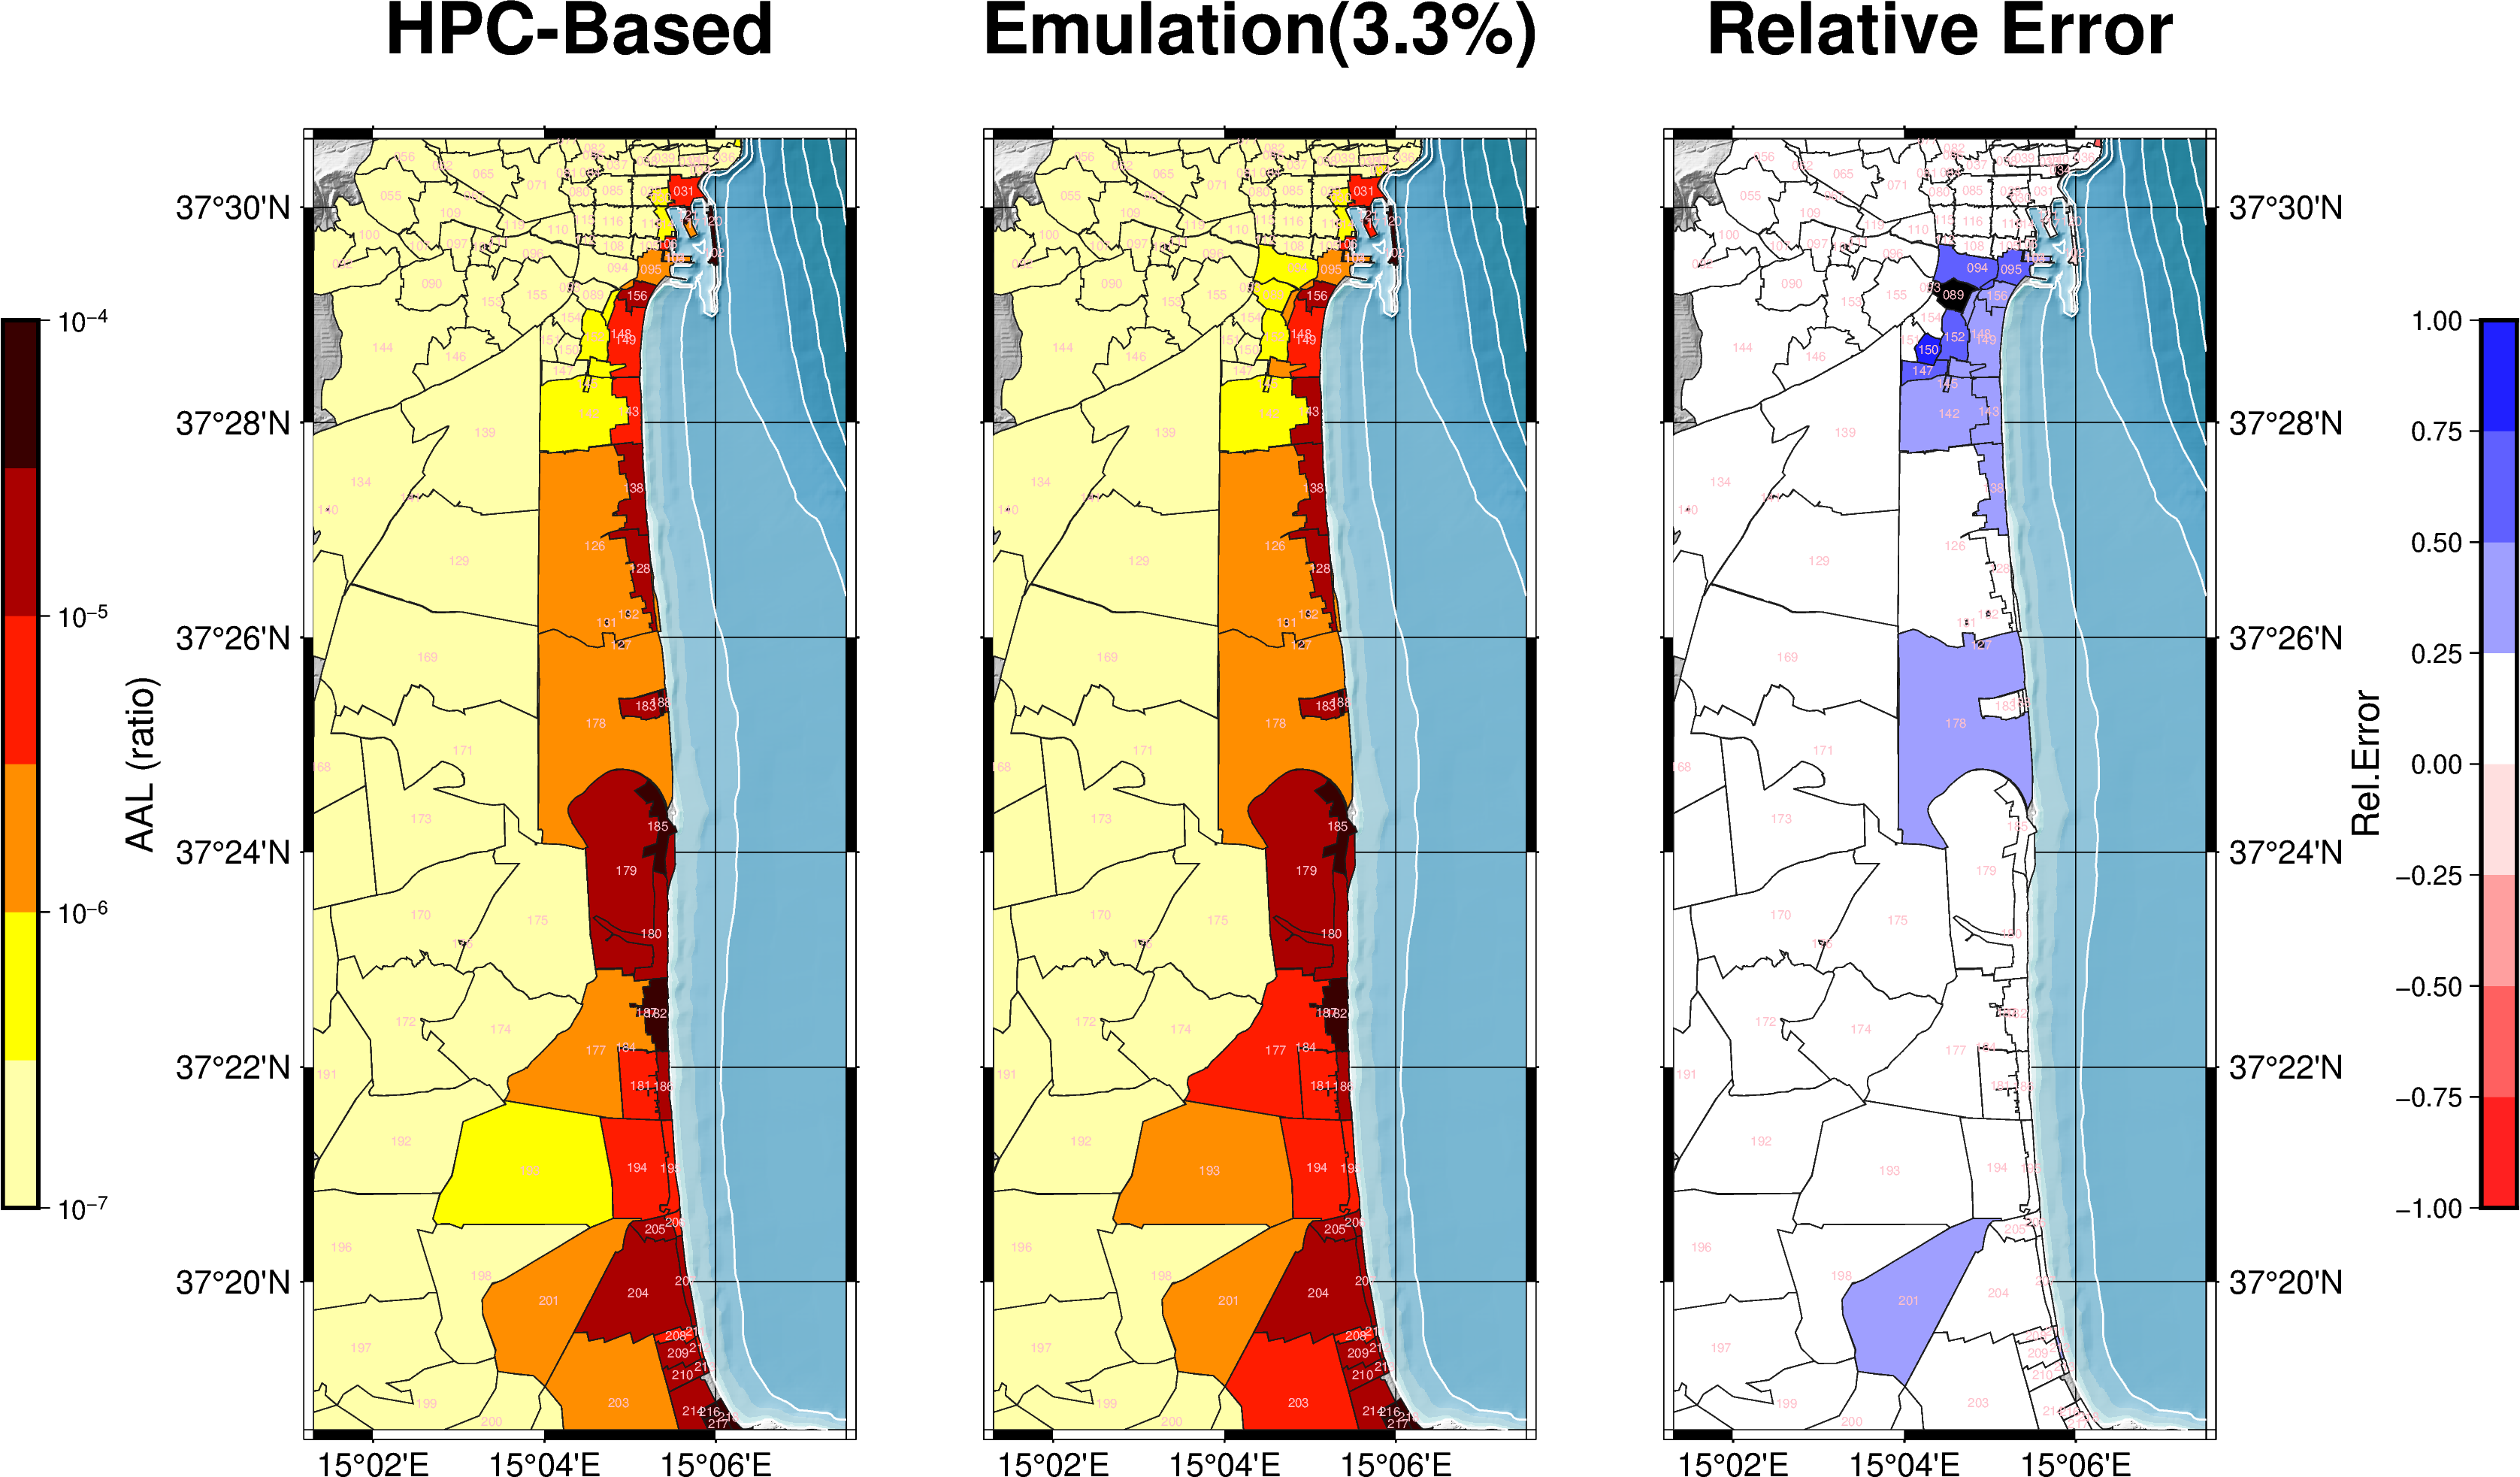

In [25]:
#read shapefile with admin boundaries
cadastral_path = f'{MLDir}/risk/exposure/Admin_units/Sicilia_cadastral.shp'
AAL_true = pd.read_csv(f'{MLDir}/risk/results/risk_calc/5_AAL_table_foglio_uncertainty_true_uncertainity.csv')[['foglio_id','value','AAL']].rename(columns={'foglio_id':'FID','AAL':'AAL_true'})
AAL_true['AAL_true'] = AAL_true['AAL_true']/AAL_true['value']
AAL_1 = pd.read_csv(f'{MLDir}/risk/results/risk_calc/5_AAL_table_foglio_uncertainty_mean_uncertainity.csv')[['foglio_id','value','AAL']].rename(columns={'foglio_id':'FID','AAL':'AAL_1'})
AAL_1['AAL_1'] = AAL_1['AAL_1']/AAL_1['value']
cadastral = gpd.read_file(cadastral_path)
cadastral = cadastral.merge(AAL_true, on='FID')
# cadastral = cadastral.merge(AAL_0, on='FID')
cadastral = cadastral.merge(AAL_1, on='FID')
# cadastral = cadastral.merge(AAL_2, on='FID')
# cadastral = cadastral.merge(AAL_3, on='FID')
cadastral['rel_err'] = (cadastral['AAL_1'] - cadastral['AAL_true'] )
cadastral['rel_err'] = cadastral['rel_err']/cadastral['AAL_true']
#set missing value to zero
cadastral['rel_err'] = cadastral['rel_err'].fillna(0)
#set values where AAL_true is less than 5e-6 to zero
cadastral.loc[cadastral['AAL_true'] < 1e-7, 'rel_err'] = 0

# plot the cadastral boundaries
fig = pygmt.Figure()
with fig.subplot(
                nrows=1,
                ncols=3,
                subsize = ["7c","20c"],
                sharey = True,
                frame = ["ag"],
                clearance  = "s3c",
                autolabel=False,
    ):
    with fig.set_panel(panel=[0,0]): #true
        #basemap
        cmap = pygmt.makecpt(cmap=cptfile_bathy,continuous=False)
        fig.grdimage(grid['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c',frame = ["+tHPC-Based"])
        fig.grdcontour(grid['z'], levels=10, pen='0.5p,white', limit=[-100, 0],projection='M6c')
        cmap = pygmt.makecpt(cmap='hot',reverse=True, log=True, series = [-7,-4,0.5],background=True)
        # cptfile = f'{MLDir}/risk/plots/cadastral_10_risk.cpt'
        # cmap = pygmt.makecpt(cmap=cptfile,continuous=False)

        fig.plot(data=cadastral,
                pen="0.3p,gray10",
                fill="+z",
                cmap=True,
                aspatial="Z=AAL_true",
                projection='M6c'
                )

        # add annotation for the cadastral boundaries
        for idx, row in cadastral.iterrows():
            x = row.geometry.centroid.x
            y = row.geometry.centroid.y
            fig.text(x=x, y=y, text=row['FOGLIO'], font='4p,pink', justify='CM',projection='M6c')

        # Add colorbar legend
        fig.colorbar(frame=["x+lAAL (ratio)","a1p"],log=True,position="jML+o-3.5c/-1c+w10c/0.4c") #add colorbar legend
  

    with fig.set_panel(panel=[0,1]): #emulation 1
        #basemap
        cmap = pygmt.makecpt(cmap=cptfile_bathy,continuous=False)
        fig.grdimage(grid['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c',frame = ["+tEmulation(3.3%)"])
        fig.grdcontour(grid['z'], levels=10, pen='0.5p,white', limit=[-100, 0],projection='M6c')

        # pygmt.makecpt(cmap="hot",series=[0,2000,50],continuous=False,reverse=True)
        # cptfile = f'{MLDir}/risk/plots/cadastral_10_risk.cpt'
        # cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
        cmap = pygmt.makecpt(cmap='hot',reverse=True, log=True, series = [-7,-4,0.5],background=True)

        fig.plot(data=cadastral,
                pen="0.3p,gray10",
                fill="+z",
                cmap=True,
                aspatial="Z=AAL_1",
                projection='M6c'
                )

        # add annotation for the cadastral boundaries
        for idx, row in cadastral.iterrows():
            x = row.geometry.centroid.x
            y = row.geometry.centroid.y
            fig.text(x=x, y=y, text=row['FOGLIO'], font='4p,pink', justify='CM',projection='M6c')
    
    with fig.set_panel(panel=[0,2]): #emulation - true /true ie relative error
        #basemap
        cmap = pygmt.makecpt(cmap=cptfile_bathy,continuous=False)
        fig.grdimage(grid['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c',frame = ["+tRelative Error"])
        fig.grdcontour(grid['z'], levels=10, pen='0.5p,white', limit=[-100, 0],projection='M6c')
        
        #make cpt for relative error -1 to 1 with diverging color
        pygmt.makecpt(cmap="polar+h0",series=[-1,1,0.25],continuous=False,reverse=True)
        
        fig.plot(data=cadastral,
                pen="0.3p,gray10",
                fill="+z",
                cmap=True,
                aspatial="Z=rel_err",
                projection='M6c'
                )

        # add annotation for the cadastral boundaries
        for idx, row in cadastral.iterrows():
            x = row.geometry.centroid.x
            y = row.geometry.centroid.y
            fig.text(x=x, y=y, text=row['FOGLIO'], font='4p,pink', justify='CM',projection='M6c')

        # Add colorbar legend
        fig.colorbar(frame=["x+lRel.Error",'a0.25'], position="jMR+o-2.5c/-1c+w10c/0.4c") #add colorbar legend

# plot legend below the map
# fig.legend(position='jBC+o-0.5c/-2c+w8c',box='+gwhite+p1p',)
fig.savefig('Map_Cadastral_AAL_uncertainty.png')
fig.show()

RP: 910298.1779915227 PoE: 1.0985411419875572e-06


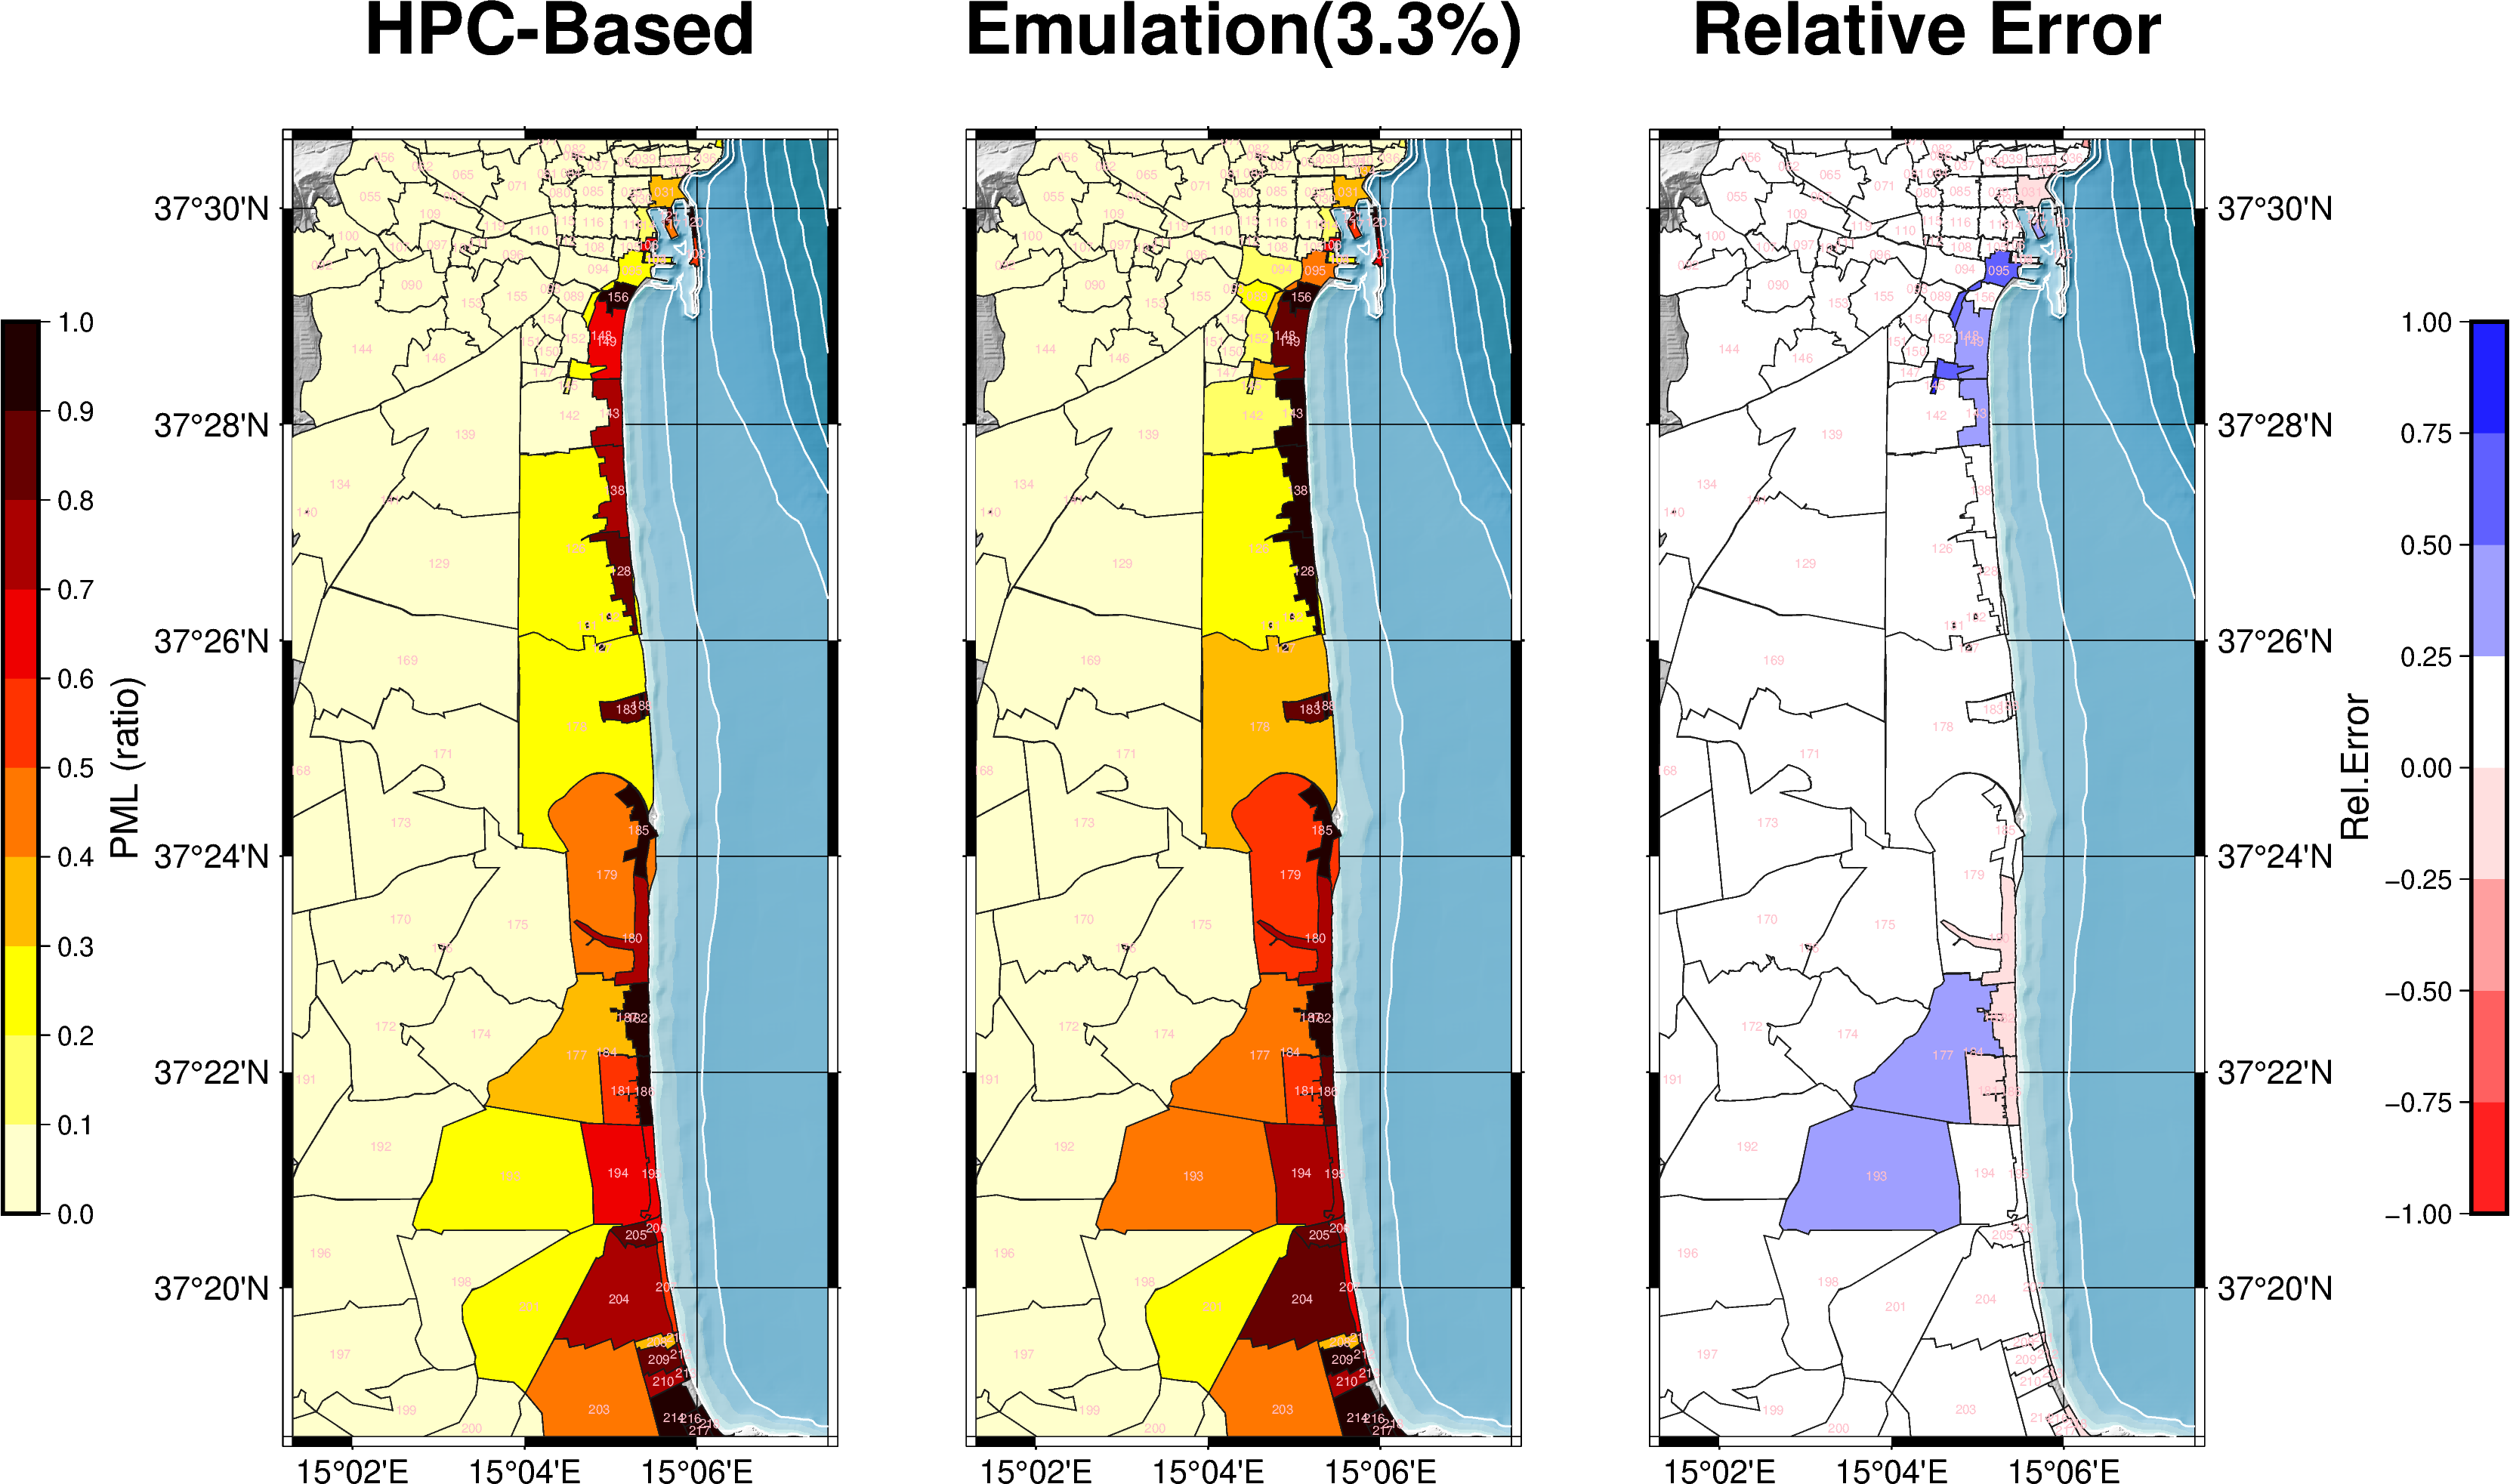

In [23]:
RP = np.logspace(3,8,50,base=10)
PoE = [1/rp for rp in RP]
#get PoE close to 1e-6
idx = (np.abs(np.array(PoE) - (1e-6))).argmin()
print(f'RP: {RP[idx]} PoE: {PoE[idx]}')

#read shapefile with admin boundaries
cadastral_path = f'{MLDir}/risk/exposure/Admin_units/Sicilia_cadastral.shp'
PML_true = pd.read_csv(f'{MLDir}/risk/results/risk_calc/4_PML_table_foglio_uncertainty_true_uncertainity.csv')[['foglio_id',f'PoE{idx}']].rename(columns={'foglio_id':'FID',f'PoE{idx}':'PML_true'})
PML_1 = pd.read_csv(f'{MLDir}/risk/results/risk_calc/4_PML_table_foglio_uncertainty_mean_uncertainity.csv')[['foglio_id',f'PoE{idx}']].rename(columns={'foglio_id':'FID',f'PoE{idx}':'PML_1'})

cadastral = gpd.read_file(cadastral_path)
cadastral = cadastral.merge(PML_true, on='FID')
cadastral = cadastral.merge(PML_1, on='FID')
cadastral['rel_err'] = (cadastral['PML_1'] - cadastral['PML_true'] )
cadastral['rel_err'] = cadastral['rel_err']/cadastral['PML_true']
cadastral['rel_err'] = cadastral['rel_err'].fillna(0)
cadastral.loc[cadastral['PML_true'] < 1e-1, 'rel_err'] = 0

# plot the cadastral boundaries
fig = pygmt.Figure()
with fig.subplot(
                nrows=1,
                ncols=3,
                subsize = ["7c","20c"],
                sharey = True,
                frame = ["ag"],
                clearance  = "s3c",
                autolabel=False,
    ):
    with fig.set_panel(panel=[0,0]): #true
        #basemap
        cmap = pygmt.makecpt(cmap=cptfile_bathy,continuous=False)
        fig.grdimage(grid['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c',frame = ["+tHPC-Based"])
        fig.grdcontour(grid['z'], levels=10, pen='0.5p,white', limit=[-100, 0],projection='M6c')

        pygmt.makecpt(cmap="hot",series=[0,1,0.1],continuous=False,reverse=True)
        fig.plot(data=cadastral,
                pen="0.3p,gray10",
                fill="+z",
                cmap=True,
                aspatial="Z=PML_true",
                projection='M6c'
                )

        # add annotation for the cadastral boundaries
        for idx, row in cadastral.iterrows():
            x = row.geometry.centroid.x
            y = row.geometry.centroid.y
            fig.text(x=x, y=y, text=row['FOGLIO'], font='4p,pink', justify='CM',projection='M6c')

        # Add colorbar legend
        fig.colorbar(frame=["x+lPML (ratio)",'a0.1'], position="jML+o-3.25c/-1c+w10c/0.4c") #add colorbar legend

    with fig.set_panel(panel=[0,1]): #emulation 1
        #basemap
        cmap = pygmt.makecpt(cmap=cptfile_bathy,continuous=False)
        fig.grdimage(grid['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c',frame = ["+tEmulation(3.3%)"])
        fig.grdcontour(grid['z'], levels=10, pen='0.5p,white', limit=[-100, 0],projection='M6c')

        pygmt.makecpt(cmap="hot",series=[0,1,0.1],continuous=False,reverse=True)
        fig.plot(data=cadastral,
                pen="0.3p,gray10",
                fill="+z",
                cmap=True,
                aspatial="Z=PML_1",
                projection='M6c'
                )

        # add annotation for the cadastral boundaries
        for idx, row in cadastral.iterrows():
            x = row.geometry.centroid.x
            y = row.geometry.centroid.y
            fig.text(x=x, y=y, text=row['FOGLIO'], font='4p,pink', justify='CM',projection='M6c')
    
    with fig.set_panel(panel=[0,2]): #emulation - true /true ie relative error
        #basemap
        cmap = pygmt.makecpt(cmap=cptfile_bathy,continuous=False)
        fig.grdimage(grid['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c',frame = ["+tRelative Error"])
        fig.grdcontour(grid['z'], levels=10, pen='0.5p,white', limit=[-100, 0],projection='M6c')
        
        #make cpt for relative error -1 to 1 with diverging color
        pygmt.makecpt(cmap="polar+h0",series=[-1,1,0.25],continuous=False,reverse=True)
        
        fig.plot(data=cadastral,
                pen="0.3p,gray10",
                fill="+z",
                cmap=True,
                aspatial="Z=rel_err",
                projection='M6c'
                )

        # add annotation for the cadastral boundaries
        for idx, row in cadastral.iterrows():
            x = row.geometry.centroid.x
            y = row.geometry.centroid.y
            fig.text(x=x, y=y, text=row['FOGLIO'], font='4p,pink', justify='CM',projection='M6c')

        # Add colorbar legend
        fig.colorbar(frame=["x+lRel.Error",'a0.25'], position="jMR+o-2.5c/-1c+w10c/0.4c") #add colorbar legend

# plot legend below the map
# fig.legend(position='jBC+o-0.5c/-2c+w8c',box='+gwhite+p1p',)
fig.savefig(f'Map_Cadastral_PML_uncertainity.png')
fig.show()

RP: 910298.1779915227 PoE: 1.0985411419875572e-06


grdimage [WARNING]: (w - x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdimage [WARNING]: w reset from 15.066 to 15.0659782445
grdimage [WARNING]: (e - x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdimage [WARNING]: e reset from 15.1 to 15.1000133702
grdimage [WARNING]: (s - y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
grdimage [WARNING]: s reset from 37.375 to 37.3749795471
grdimage [WARNING]: (n - y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
grdimage [WARNING]: n reset from 37.408333 to 37.4083339702


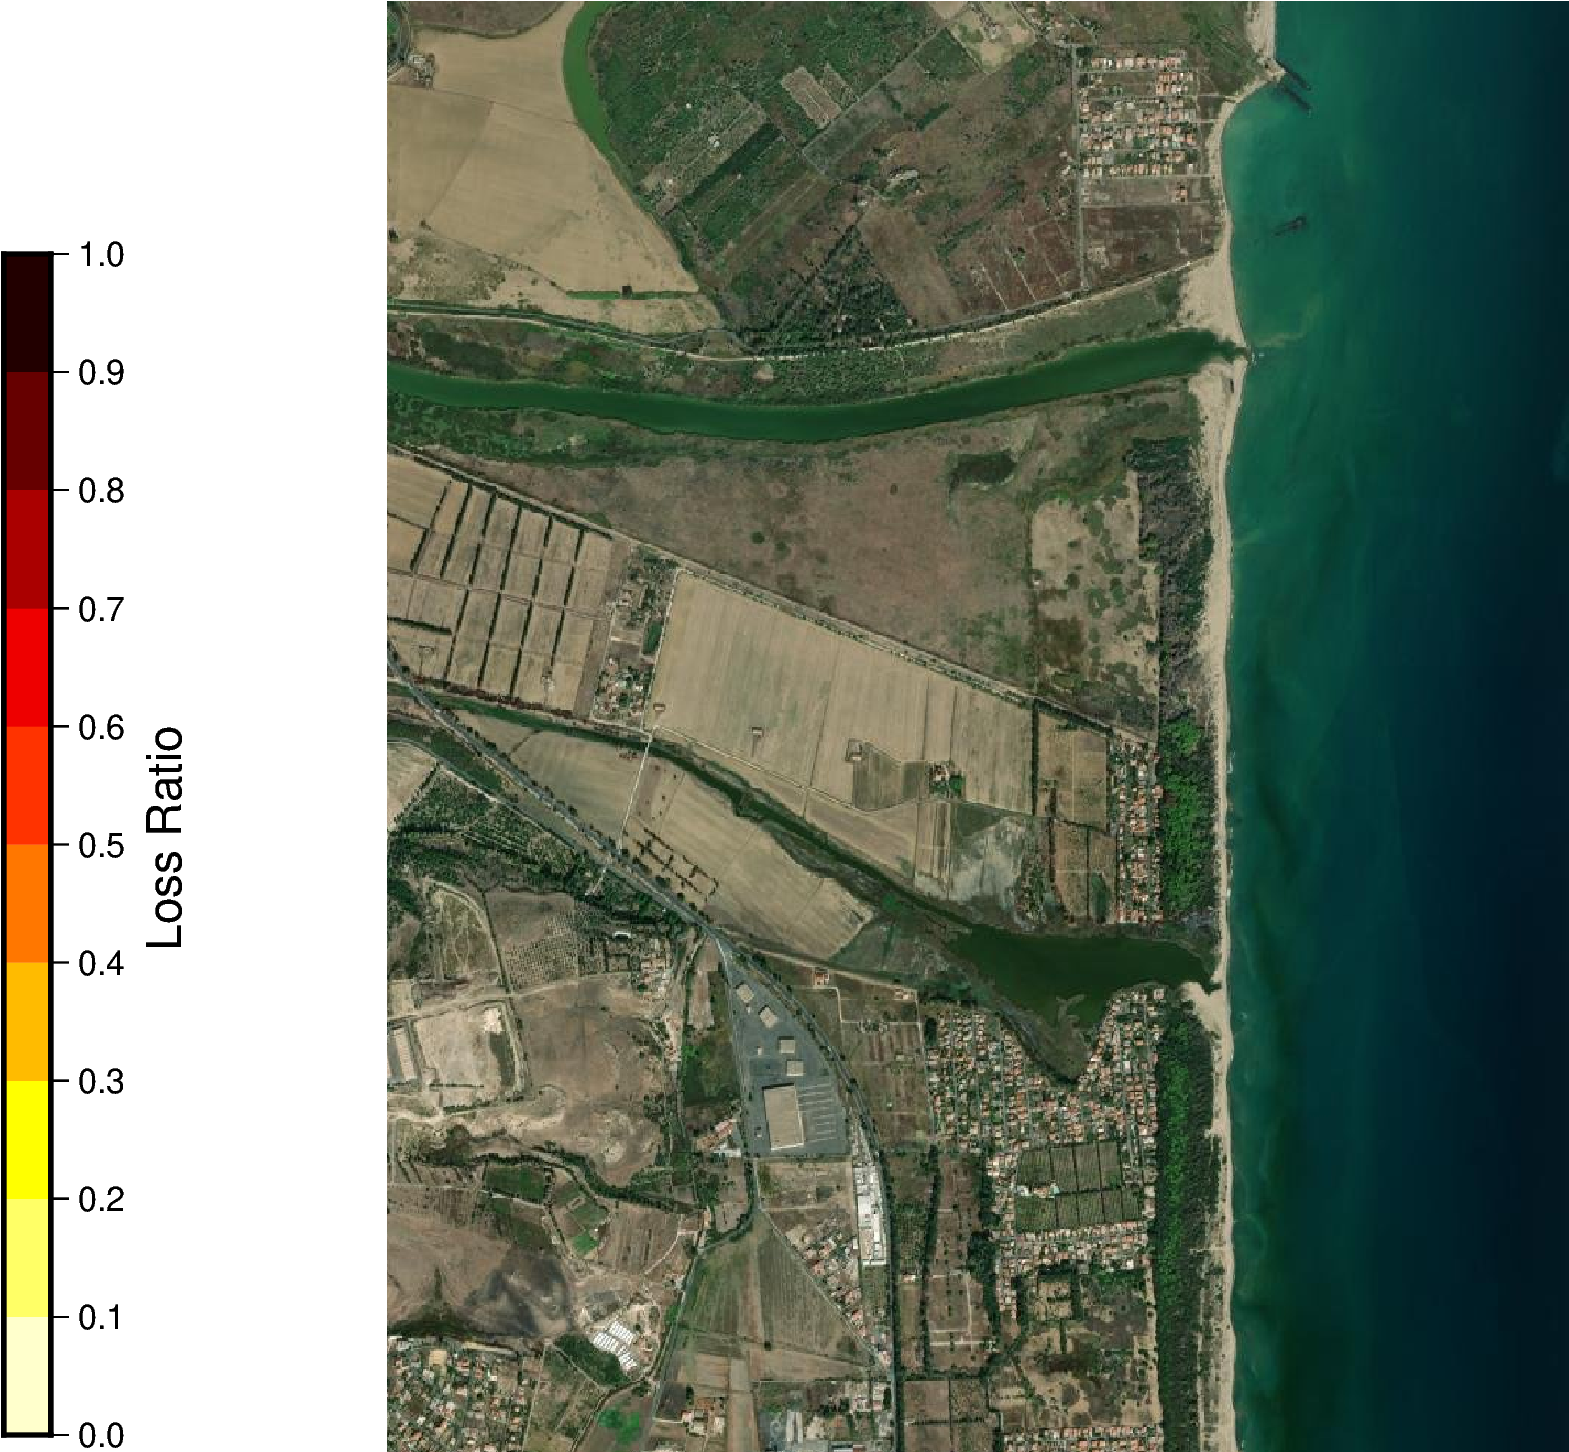

In [8]:
import os
import sys
os.environ['MPLCONFIGDIR'] = os.getcwd() + "/configs/"
import geopandas as gpd
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pygmt
import pyogrio
pyogrio.core._register_drivers()
import rioxarray
import contextily as cx

os.environ['MPLCONFIGDIR'] = os.getcwd() + "/configs/"


MLDir = os.getenv('MLDir')
SimDir = os.getenv('SimDir')
reg = 'CT'
train_size = '1658'
mask_size = '892'

eve_id = np.loadtxt(f'{MLDir}/data/events/sample_events53550.txt',dtype='str')   
#inundation attributes
flood_mask = ~np.load(f'{MLDir}/data/processed/zero_mask_{reg}_{mask_size}.npy')
nflood_grids = np.count_nonzero(flood_mask)
zero_mask = np.load(f'{MLDir}/data/processed/zero_mask_{reg}_{mask_size}.npy')
index_map = pd.read_csv(f'{MLDir}/data/processed/lat_lon_idx_{reg}_{mask_size}.txt',sep=',',header=None)
index_map.columns = ['m','n','lat','lon'] #add column names

GaugeNo = list(range(35,44)) #for Catania
columnname = str(38)
x_dim = 912
y_dim = 2224
ts_dim = len(GaugeNo)
pts_dim = 480
list_size = ['892','1658','3454','7071'] 
control_points =  [[37.5022,15.0960],
    [37.48876,15.08936],
    [37.47193,15.07816],
    [37.46273,15.08527],
    [37.46252,15.08587],
    [37.45312,15.07874],
    [37.42821,15.08506],
    [37.40958,15.08075],
    [37.38595,15.08539],
    [37.35084,15.08575],
    [37.33049,15.07029],
    [37.40675,15.05037]]

# Load the elevation from netcdf grid
grid = xr.open_dataset('../../data/processed/CT_defbathy.nc',engine='netcdf4')
ymin = grid['y'].min().values
ymax = grid['y'].max().values
xmin = grid['x'].min().values
xmax = grid['x'].max().values
cptfile_bathy = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/scripts/PaperIIPlots/PaperI/r2/bathy_error.cpt'  
xmin,xmax,ymin,ymax = 15.066,15.10,37.375,37.408333
RP = np.logspace(3,8,50,base=10)
PoE = [1/rp for rp in RP]
#get PoE close to 1e-6
idx = (np.abs(np.array(PoE) - 1e-6)).argmin()
print(f'RP: {RP[idx]} PoE: {PoE[idx]}')

#read geopackage file with building polygons
file_path = f'{MLDir}/risk/exposure/CT_Building_Footprint.gpkg'
buildings_footprint = gpd.read_file(file_path,  layer='Building_Footprint')
buildings_attributes = gpd.read_file(file_path,  layer='Building_Attributes')
buildings_exposure = gpd.read_file(file_path, layer='Building_ExposureInfo')

PML_true = pd.read_csv(f'{MLDir}/risk/results/risk_calc/4_PML_table_asset_true.csv')[['IDAG',f'PoE{idx}']].rename(columns={f'PoE{idx}':'PML_true'})
buildings_footprint = buildings_footprint.merge(PML_true, on='IDAG')


# plot the buildings
fig = pygmt.Figure()

#basemap
fig.tilemap(
        region=[xmin,xmax,ymin,ymax],
        projection="M10c",
        zoom=15,
        source=cx.providers.Esri.WorldImagery,)

pygmt.makecpt(cmap="hot",series=[0,1,0.1],continuous=False,reverse=True)

# fig.plot(data=buildings_footprint,
#         pen=None,
#         fill="+z",
#         cmap=True,
#         aspatial="Z=PML_true",
#         projection='M10c',
#         region=[xmin,xmax,ymin,ymax],
#         )

# Add colorbar legend
fig.colorbar(frame=["x+l Loss Ratio",'a0.1'], position="jML+o-3.25c/-1c+w10c/0.4c") #add colorbar legend
fig.savefig("imagery.png",transparent=True)
fig.show()